In [1]:
import os
import io
from io import BytesIO
import gzip
import json
import pickle
import warnings
import logging

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

import matplotlib.pyplot as plt
import seaborn as sns

from tqdm import tqdm
from dotenv import load_dotenv
from transformers import EsmForMaskedLM, EsmTokenizer
from peft import LoraConfig, get_peft_model
from google.cloud import storage

from scipy.stats import wilcoxon
from statsmodels.stats.multitest import multipletests

warnings.filterwarnings("ignore")
logging.getLogger("transformers").setLevel(logging.ERROR)

/opt/anaconda3/envs/MachLearn/lib/python3.12/site-packages/seaborn/_statistics.py:32: UserWarning: A NumPy version >=1.22.4 and <2.3.0 is required for this version of SciPy (detected version 2.4.6)
  from scipy.stats import gaussian_kde
/opt/anaconda3/envs/MachLearn/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [5]:
# metadata_df_clean.to_csv("/Users/johnhutchens/Desktop/Practicum/Data/Spearman_Data/metadata_ESM2_PFAM_ALL.csv.gz", compression="gzip")
metadata_df_clean = pd.read_csv("/Users/johnhutchens/Desktop/Practicum/Data/Spearman_Data/metadata_ESM2_PFAM_ALL.csv.gz", index_col=0)

In [6]:
plot_df = metadata_df_clean[metadata_df_clean["n_domains"] > 4].copy()

In [7]:
plot_df.head()

,run_id,pfam_id,n_domains,random_seed,lr,lora_r,lora_alpha,baseline_mean_val_rho,mean_delta_val_rho,mean_delta_test_rho,model
0,global_finetune,NaN,522,42,0.0005,64,128,0.447091,0.040047,0.040093,ALL
2,global_finetune/PF00013,global_finetune,9,42,0.0050,16,32,0.459562,0.144605,0.133590,PF00013
3,global_finetune/PF00018,global_finetune,36,42,0.0001,16,32,0.562982,0.002270,0.002699,PF00018
4,global_finetune/PF00030,global_finetune,12,42,0.0050,8,16,0.412190,-0.049657,-0.036689,PF00030
6,global_finetune/PF00046,global_finetune,37,42,0.0050,16,32,0.382362,-0.087750,-0.084862,PF00046


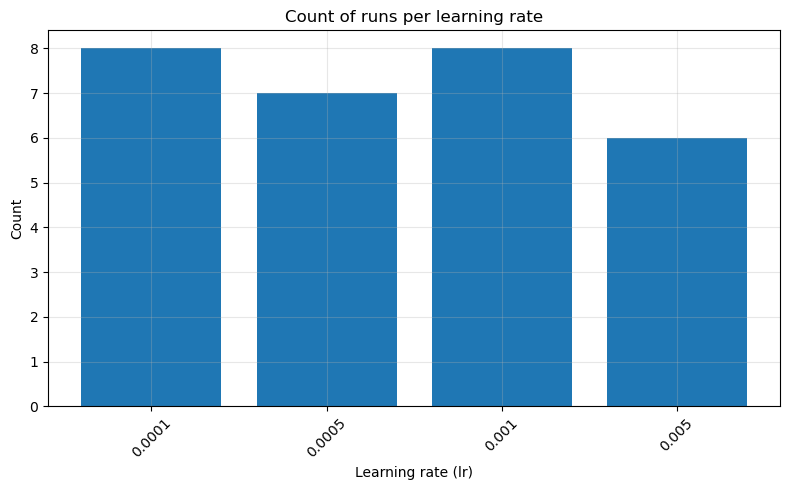

In [8]:
df = plot_df

lr_counts = df["lr"].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(8, 5))

ax.bar(lr_counts.index.astype(str), lr_counts.values)

ax.set_xlabel("Learning rate (lr)")
ax.set_ylabel("Count")
ax.set_title("Count of runs per learning rate")
ax.grid(alpha=0.3)

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

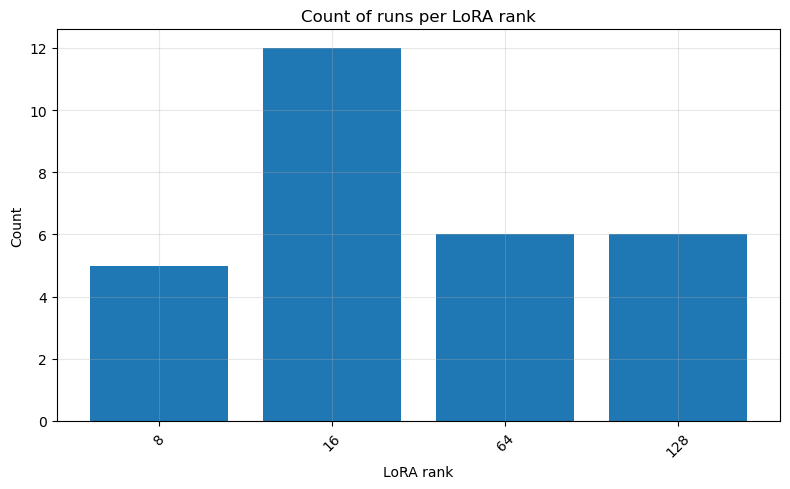

In [9]:
df = plot_df

lora_r_counts = df["lora_r"].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(8, 5))

ax.bar(lora_r_counts.index.astype(str), lora_r_counts.values)

ax.set_xlabel("LoRA rank")
ax.set_ylabel("Count")
ax.set_title("Count of runs per LoRA rank")
ax.grid(alpha=0.3)

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

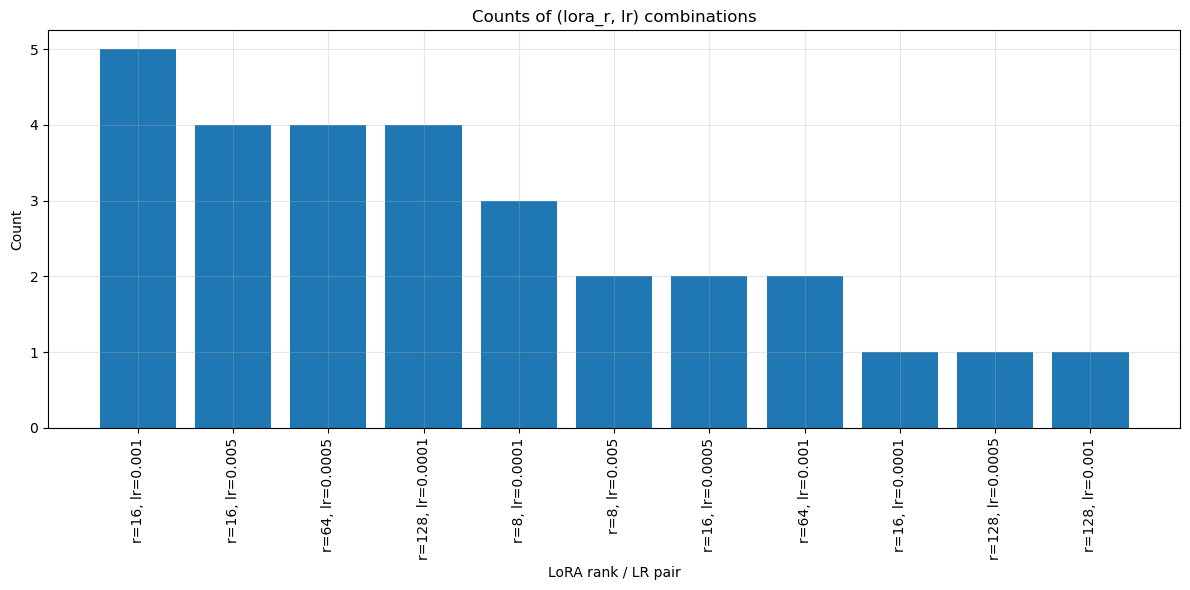

In [16]:
pair_counts = (
    df.groupby(["lora_r", "lr"])
    .size()
    .reset_index(name="count")
    .sort_values("count", ascending=False)
)

pair_counts["pair"] = (
    "r=" + pair_counts["lora_r"].astype(str)
   +  ", lr=" + pair_counts["lr"].astype(str) 
)

fig, ax = plt.subplots(figsize=(12, 6))

ax.bar(
    pair_counts["pair"],
    pair_counts["count"]
)

ax.set_xlabel("LoRA rank / LR pair")
ax.set_ylabel("Count")
ax.set_title("Counts of (lora_r, lr) combinations")
ax.grid(alpha=0.3)

plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

In [18]:
pair_counts.sort_values(["lora_r", "lr"], inplace=True)

In [19]:
pair_counts[["pair", "count"]]

,pair,count
0,"r=8, lr=0.0001",3
1,"r=8, lr=0.005",2
2,"r=16, lr=0.0001",1
3,"r=16, lr=0.0005",2
4,"r=16, lr=0.001",5
5,"r=16, lr=0.005",4
6,"r=64, lr=0.0005",4
7,"r=64, lr=0.001",2
8,"r=128, lr=0.0001",4
9,"r=128, lr=0.0005",1


## Do something with other columns?

# Metadata from single domains